# Ch11 Playground — 抽象向量空間 Abstract Vector Spaces

> 對應 3Blue1Brown《線性代數的本質》第十一章（最終章）
>
> 我們從 Ch1 一路走來，把向量想成「箭頭」或「一串數字」。但這集要問：**「向量到底是什麼？」**
>
> 答案出乎意料：**任何遵守 8 條規則（公理）的東西**都可以當向量。

## 為什麼要抽象化？

考慮幾個事實：
- 兩個函數可以相加：$(f+g)(x) = f(x) + g(x)$
- 函數可以乘純量：$(c\,f)(x) = c \cdot f(x)$
- 微分運算 $D: f \mapsto f'$ 滿足線性：$D(f+g) = Df + Dg$，$D(cf) = c\,Df$

這些行為跟「向量加法、純量乘、線性變換」一模一樣！既然規則一樣，為什麼不能套用線性代數的全部工具（基底、座標、特徵向量…）到函數上？

**Ch11 的答案是：可以**。只要你的物件滿足 8 條公理，整套線性代數機器就會自動運作。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print('✔ Setup ready.')

✔ Setup ready.


---
## Part 1：函數其實也是向量

對函數來說：
- **加法**：$(f + g)(x) = f(x) + g(x)$ — 在每個 $x$ 把值相加
- **純量乘**：$(c f)(x) = c \cdot f(x)$ — 整條曲線統一拉長

這跟向量做 $\vec{u} + \vec{v}$ 和 $c\vec{v}$ 完全是同一種運算。**所以函數的全體就是一個「向量空間」**，只是這個空間是**無窮維**的。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3588909808.py:22: UserWarning: Glyph 20841 (\N{CJK UNIFIED IDEOGRAPH-5169}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3588909808.py:22: UserWarning: Glyph 26781 (\N{CJK UNIFIED IDEOGRAPH-689D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3588909808.py:22: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3588909808.py:22: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3588909808.py:22: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu

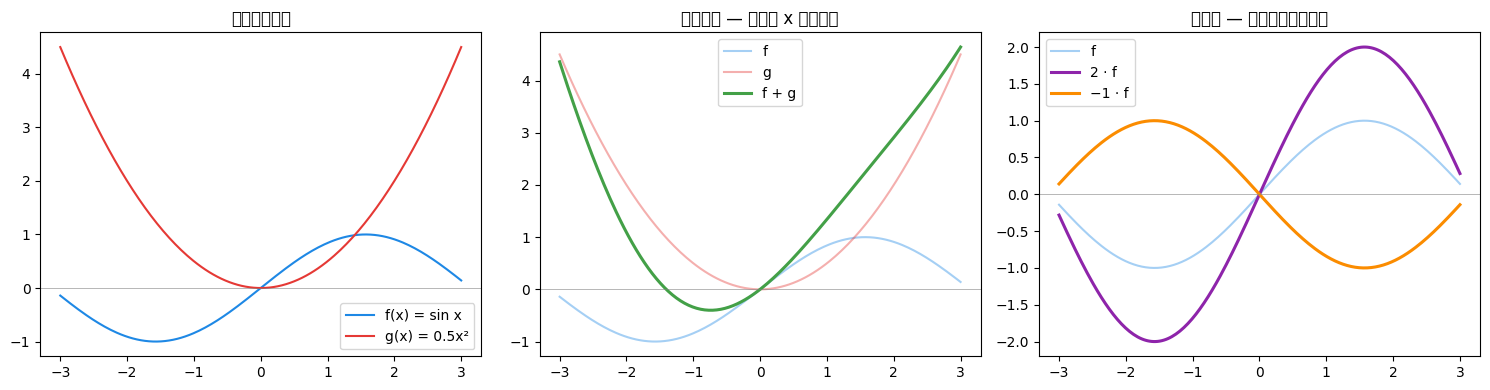

In [2]:
# === 實驗 1：把兩個函數相加 + 純量乘 ===

x = np.linspace(-3, 3, 200)
f = np.sin(x)
g = 0.5 * x ** 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x, f, color='#1E88E5', label='f(x) = sin x')
axes[0].plot(x, g, color='#E53935', label='g(x) = 0.5x²')
axes[0].set_title('兩條函數曲線'); axes[0].legend(); axes[0].axhline(0, color='grey', lw=0.4)

axes[1].plot(x, f, color='#1E88E5', alpha=0.4, label='f')
axes[1].plot(x, g, color='#E53935', alpha=0.4, label='g')
axes[1].plot(x, f + g, color='#43A047', lw=2.2, label='f + g')
axes[1].set_title('函數加法 — 在每個 x 把值相加'); axes[1].legend(); axes[1].axhline(0, color='grey', lw=0.4)

axes[2].plot(x, f, color='#1E88E5', alpha=0.4, label='f')
axes[2].plot(x, 2 * f, color='#8E24AA', lw=2.2, label='2 · f')
axes[2].plot(x, -1 * f, color='#FB8C00', lw=2.2, label='−1 · f')
axes[2].set_title('純量乘 — 整條曲線統一伸縮'); axes[2].legend(); axes[2].axhline(0, color='grey', lw=0.4)

plt.tight_layout(); plt.show()

---
## Part 2：微分是線性變換

**線性變換的定義（廣義）**：函數 $L$ 滿足
1. $L(\vec{v} + \vec{w}) = L(\vec{v}) + L(\vec{w})$
2. $L(c\,\vec{v}) = c \cdot L(\vec{v})$

考慮**微分運算 $D(f) = \dfrac{df}{dx}$**：
1. $\dfrac{d}{dx}(f + g) = \dfrac{df}{dx} + \dfrac{dg}{dx}$ ✔
2. $\dfrac{d}{dx}(c f) = c \dfrac{df}{dx}$ ✔

微積分課本沒這樣講，但**微分就是一種線性變換**。既然是線性變換，原則上就能寫成「矩陣」 — 只要先選好基底。

In [3]:
# === 實驗 2：用數值驗證微分的線性 ===
# 用有限差分當作微分的近似

def D(y, x):
    return np.gradient(y, x)

x = np.linspace(-3, 3, 401)
f = np.sin(x)
g = x ** 3
c = 2.5

# 可加性：D(f+g) ≈ Df + Dg
lhs1 = D(f + g, x)
rhs1 = D(f, x) + D(g, x)
print('D(f+g) ≈ Df + Dg ?', np.allclose(lhs1, rhs1, atol=1e-8))

# 齊次性：D(c f) ≈ c · Df
lhs2 = D(c * f, x)
rhs2 = c * D(f, x)
print('D(c·f) ≈ c·Df ?  ', np.allclose(lhs2, rhs2, atol=1e-8))

D(f+g) ≈ Df + Dg ? True
D(c·f) ≈ c·Df ?   True


---
## Part 3：把多項式當向量 — 微分變成一個漂亮的矩陣

為了讓「微分 = 矩陣」具體一點，我們不取所有函數，只取**多項式**這個子空間，再限制到次數 $\leq 4$ 的多項式：

$$ V = \{a_0 + a_1 x + a_2 x^2 + a_3 x^3 + a_4 x^4 \,:\, a_i \in \mathbb{R}\} $$

這是個**5 維向量空間**！自然基底是：

$$ \{1,\; x,\; x^2,\; x^3,\; x^4\} $$

任何多項式 $p$ 都能用 $(a_0, a_1, a_2, a_3, a_4)$ 這 5 個係數唯一表示。**「多項式」就變成了「5 維向量」**。

**微分把每個基底向量變成什麼？**
- $\dfrac{d}{dx}(1) = 0$
- $\dfrac{d}{dx}(x) = 1$
- $\dfrac{d}{dx}(x^2) = 2x$
- $\dfrac{d}{dx}(x^3) = 3x^2$
- $\dfrac{d}{dx}(x^4) = 4x^3$

把每個結果寫成 5 維座標當 column，就得到**微分運算的矩陣表示**：

$$ D = \begin{bmatrix} 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 2 & 0 & 0 \\ 0 & 0 & 0 & 3 & 0 \\ 0 & 0 & 0 & 0 & 4 \\ 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

In [4]:
# === 實驗 3：把微分寫成 5×5 矩陣，並用矩陣乘法做微分 ===

# 基底：1, x, x², x³, x⁴；多項式以係數向量 (a0, a1, a2, a3, a4) 表示
D_mat = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 2, 0, 0],
    [0, 0, 0, 3, 0],
    [0, 0, 0, 0, 4],
    [0, 0, 0, 0, 0],
], dtype=float)
print('微分矩陣 D =\n', D_mat)

# 例：p(x) = 5 + 3x − 2x² + x³ − 4x⁴
p = np.array([5, 3, -2, 1, -4], dtype=float)

# 矩陣作用於 p
Dp = D_mat @ p
print("\np(x) = 5 + 3x − 2x² + x³ − 4x⁴")
print("D @ p =", Dp, "  →  p'(x) = 3 + (-4)x + 3x² + (-16)x³")

# 對照：手算微分後的多項式應該是 3 − 4x + 3x² − 16x³
expected = np.array([3, -4, 3, -16, 0], dtype=float)
print('一致？', np.allclose(Dp, expected))

# 連續做兩次微分 = 矩陣相乘
DD = D_mat @ D_mat
print("\nD² (二階微分矩陣) =\n", DD)
print("D² @ p =", DD @ p, "  →  p''(x) = -4 + 6x − 48x²")
expected2 = np.array([-4, 6, -48, 0, 0], dtype=float)
print('一致？', np.allclose(DD @ p, expected2))

微分矩陣 D =
 [[0. 1. 0. 0. 0.]
 [0. 0. 2. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 4.]
 [0. 0. 0. 0. 0.]]

p(x) = 5 + 3x − 2x² + x³ − 4x⁴
D @ p = [  3.  -4.   3. -16.   0.]   →  p'(x) = 3 + (-4)x + 3x² + (-16)x³
一致？ True

D² (二階微分矩陣) =
 [[ 0.  0.  2.  0.  0.]
 [ 0.  0.  0.  6.  0.]
 [ 0.  0.  0.  0. 12.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
D² @ p = [ -4.   6. -48.   0.   0.]   →  p''(x) = -4 + 6x − 48x²
一致？ True


---
## Part 4：視覺化 — 矩陣作用 vs. 真正的微分

把 $p(x)$ 的圖和 $D@p$（矩陣作用）的圖、以及對 $p(x)$ 真正取極限的微分結果一起畫，三條應該完全一致。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3973371952.py:18: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3973371952.py:18: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3973371952.py:18: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3973371952.py:18: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_47555/3973371952.py:18: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu

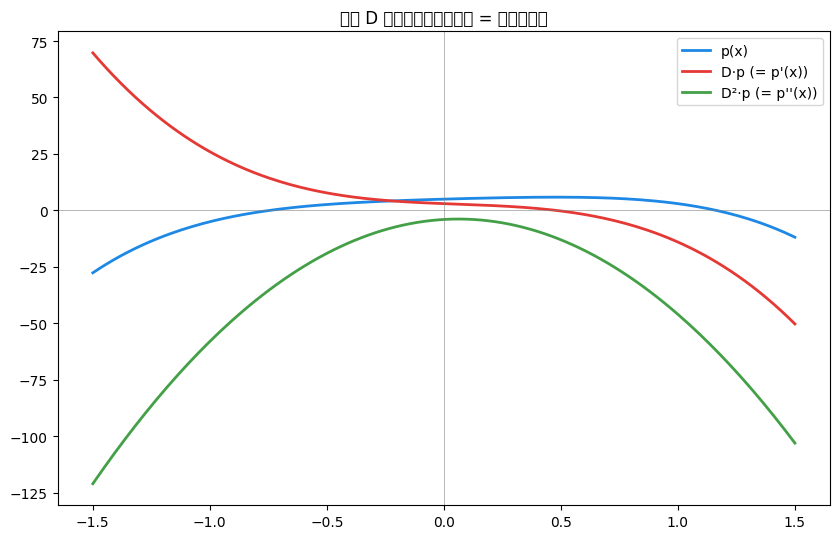

In [5]:
# === 實驗 4：視覺對照 ===

def poly_eval(coeffs, x):
    """係數 (a0..a4) 在 x 點取值"""
    return sum(a * x ** i for i, a in enumerate(coeffs))

p = np.array([5, 3, -2, 1, -4], dtype=float)
Dp = D_mat @ p
DDp = D_mat @ Dp

x = np.linspace(-1.5, 1.5, 200)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(x, poly_eval(p,   x), color='#1E88E5', lw=2,   label='p(x)')
ax.plot(x, poly_eval(Dp,  x), color='#E53935', lw=2,   label="D·p (= p'(x))")
ax.plot(x, poly_eval(DDp, x), color='#43A047', lw=2,   label="D²·p (= p''(x))")
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
ax.legend(); ax.set_title('矩陣 D 作用在多項式向量上 = 真正的微分')
plt.tight_layout(); plt.show()

---
## Part 5：八條公理 — 抽象向量空間的「身分證」

一個集合 $V$ 配上「加法」和「純量乘」，要滿足以下 **8 條公理**才能稱為向量空間。看起來繁瑣，但本質就是「加法應該像加法、伸縮應該像伸縮」。

對所有 $\vec{u}, \vec{v}, \vec{w} \in V$，所有 $a, b \in \mathbb{R}$：

1. $\vec{u} + \vec{v} \in V$（加法封閉）
2. $(\vec{u} + \vec{v}) + \vec{w} = \vec{u} + (\vec{v} + \vec{w})$（結合）
3. $\vec{u} + \vec{v} = \vec{v} + \vec{u}$（交換）
4. 存在 $\vec{0}$ 使得 $\vec{v} + \vec{0} = \vec{v}$（零向量）
5. 對每個 $\vec{v}$ 存在 $-\vec{v}$ 使得 $\vec{v} + (-\vec{v}) = \vec{0}$（加法逆元）
6. $a(\vec{u} + \vec{v}) = a\vec{u} + a\vec{v}$（純量分配律 1）
7. $(a + b)\vec{v} = a\vec{v} + b\vec{v}$（純量分配律 2）
8. $a(b\vec{v}) = (ab)\vec{v}$ 且 $1 \cdot \vec{v} = \vec{v}$（結合 + 單位元）

**3B1B 的關鍵洞見**：所有線性代數的定理（線性變換、基底、特徵值、對偶性、…）都只用到這 8 條公理。所以**任何滿足這 8 條的東西**，都自動繼承所有這些工具。

### 滿足這 8 條的「向量空間」例子

| 例子 | 元素長什麼樣 | 維度 |
|---|---|---|
| $\mathbb{R}^n$ | $(a_1, \ldots, a_n)$ | $n$ |
| 多項式 $\leq n$ 次 | $a_0 + a_1 x + \cdots + a_n x^n$ | $n+1$ |
| 所有連續函數 $C[\mathbb{R}]$ | $f(x)$ | 無窮 |
| $m \times n$ 矩陣 | $M$ | $m \cdot n$ |
| 機率分佈（在某些限制下）| $p_i$ | 視情形 |
| 訊號 / 序列 | $(s_0, s_1, s_2, \ldots)$ | 無窮 |

In [6]:
# === 實驗 5：把矩陣自己當成「向量」 ===

# 2×2 矩陣的全體，是一個 4 維向量空間（自然基底是 4 個 'e_ij' 矩陣）
M1 = np.array([[1, 2], [3, 4]], dtype=float)
M2 = np.array([[0, 1], [1, 0]], dtype=float)

# 加法封閉、純量乘 — 滿足前面所有公理
print('M1 + M2 =\n', M1 + M2)
print('\n3 * M1 =\n', 3 * M1)

# 把 2×2 矩陣攤平成 4 維向量（一個合法的基底坐標）
v_M1 = M1.flatten()
print('\n把 M1 當 4 維向量看：', v_M1)
print('這就是矩陣空間的一組座標。')

M1 + M2 =
 [[1. 3.]
 [4. 4.]]

3 * M1 =
 [[ 3.  6.]
 [ 9. 12.]]

把 M1 當 4 維向量看： [1. 2. 3. 4.]
這就是矩陣空間的一組座標。


---
## 總結

| 概念 | 教過的具體版本 | 抽象推廣 |
|---|---|---|
| 向量 | 箭頭 / 數字串 | 任何滿足 8 條公理的元素 |
| 線性變換 | 矩陣 | 任何滿足 $L(\vec{u}+\vec{v}) = L\vec{u}+L\vec{v}$、$L(c\vec{v}) = cL\vec{v}$ 的映射 |
| 基底 | $\hat{i}, \hat{j}, \hat{k}$ | 任何能線性組合得出空間中所有元素的最小集合 |
| 座標 | $(x,y,z)$ | 在所選基底下的係數 |
| 微分 | 公式 | 從函數空間到函數空間的線性變換；可寫成矩陣 |

### 一句話記住

> 線性代數的本質是「**形式而非內容**」。只要你的物件遵守 8 條規則，無論它是箭頭、函數、矩陣，還是訊號 — 你都能用一整套線性代數工具去研究它。

### 為什麼在深度學習裡這個觀點重要？

1. **Embedding 空間**：詞向量、圖片特徵、用戶向量都是向量空間中的元素。語義相似 ↔ 向量相加得出有意義的結果（「king − man + woman ≈ queen」），就是把抽象向量空間的線性結構發揮出來。
2. **函數即向量**：神經網路本身就是函數空間中的一個元素。**RKHS、核方法、高斯過程**都把函數當向量處理。
3. **訊號空間 = 向量空間**：FFT、卷積、傅立葉、小波 — 全都是「在訊號空間中換基底」。每個 layer 的 activation 也可以這樣理解。
4. **輸入 / 輸出張量**：CNN 的 feature map、transformer 的 token embedding、attention 中的 Q/K/V，都是高維向量空間中的元素。
5. **正規化與不變性**：8 條公理裡的「加法、純量乘」要尊重才能套理論工具。違反這些 (e.g. quantization, ReLU 後的非線性區段) 後就需要其他數學處理。

### 終章致謝

從 Ch1 的箭頭到 Ch11 的抽象空間，我們完成了 3Blue1Brown 整個《線性代數的本質》系列。下一步：**微積分** → **機率統計** → **進入深度學習主題**。